# Experiment: 04 Cross-Model Transfer

Objective:
- Visualize geometry transfer retention and classifier transfer by layer.
- Separate manifold transfer from decision-boundary transfer.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import matplotlib.pyplot as plt
import numpy as np

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


In [2]:
all_results = vu.load_all_results()
cross_rows = vu.collect_cross_rows(all_results)

# Build axes dynamically from whatever cross data is available.
# Falls back to Qwen/DeepSeek defaults so the notebook renders (as NaN) before analyze_cross runs.
_observed_keys = sorted({(r["model"], r["dataset"]) for r in cross_rows})
_observed_layers = sorted({r["layer"] for r in cross_rows})
row_keys = _observed_keys or [("deepseek", "gsm8k"), ("deepseek", "math500"), ("qwen", "gsm8k"), ("qwen", "math500")]
layers = _observed_layers or [7, 14, 21]

if not cross_rows:
    print("WARNING: no cross-model results found — run `dvc repro analyze_cross` first.")

def matrix(metric: str) -> np.ndarray:
    values = np.full((len(row_keys), len(layers)), np.nan)
    for row in cross_rows:
        key = (row["model"], row["dataset"])
        if key not in row_keys or row["layer"] not in layers:
            continue
        i = row_keys.index(key)
        j = layers.index(row["layer"])
        values[i, j] = row[metric]
    return values

transfer_pct = matrix("transfer_pct")
cross_mahal = matrix("cross_mahal_auc")
clf_mahal = matrix("clf_transfer_mahal_auc")
clf_combined = matrix("clf_transfer_combined_auc")


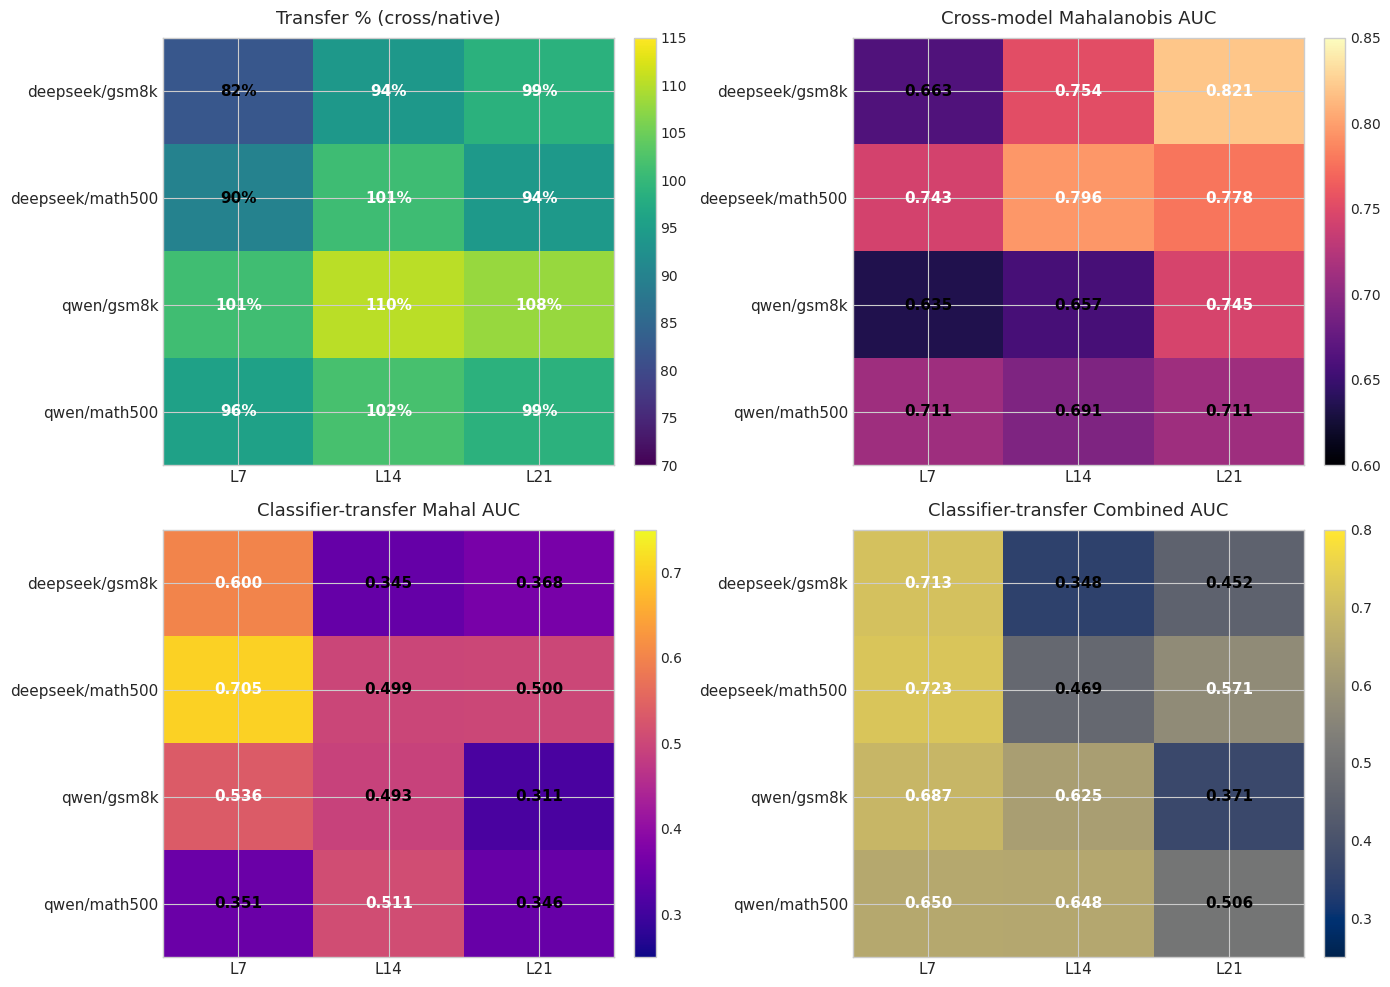

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
items = [
    (transfer_pct, "Transfer % (cross/native)", "viridis", (70, 115)),
    (cross_mahal,  "Cross-model Mahalanobis AUC", "magma",  (0.6, 0.85)),
    (clf_mahal,    "Classifier-transfer Mahal AUC", "plasma", (0.25, 0.75)),
    (clf_combined, "Classifier-transfer Combined AUC", "cividis", (0.25, 0.8)),
]
row_labels = [f"{m}/{d}" for m, d in row_keys]

for ax, (data, title, cmap, limits) in zip(axes.ravel(), items):
    image = ax.imshow(data, aspect="auto", cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set_title(title, pad=10)
    ax.set_xticks(np.arange(len(layers)))
    ax.set_xticklabels([f"L{l}" for l in layers], fontsize=10, rotation=45 if len(layers) > 4 else 0)
    ax.set_yticks(np.arange(len(row_keys)))
    ax.set_yticklabels(row_labels, fontsize=11)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if np.isnan(v):
                continue
            text = f"{v:.0f}%" if "%" in title else f"{v:.3f}"
            # Pick white or black text based on relative position in colormap range
            normed = (v - limits[0]) / (limits[1] - limits[0])
            color = "white" if normed > 0.5 else "black"
            ax.text(j, i, text, ha="center", va="center", color=color, fontsize=11, fontweight="bold")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
plt.show()
